In [2]:
!pip install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.9 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.37
    Uninstalling SQLAlchemy-2.0.37:
      Successfully uninstalled SQLAlchemy-2.0.37
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


Descargando datos de la estación: ANMO
Datos guardados en: ANMO_Tohoku_2011.mseed
Error with this phase, skipping it: pp
Error with this phase, skipping it: ppp


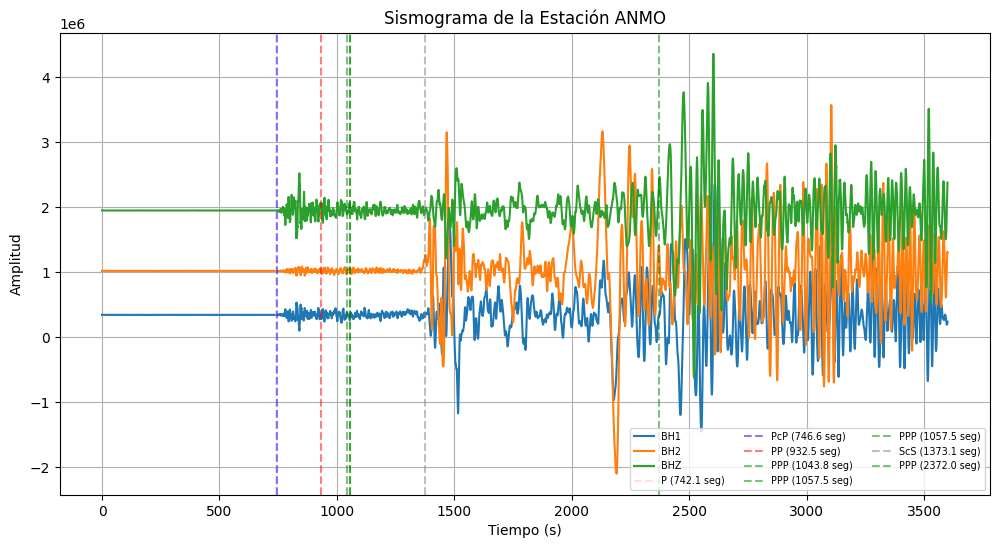

Descargando datos de la estación: COLA
Datos guardados en: COLA_Tohoku_2011.mseed
Error with this phase, skipping it: pp
Error with this phase, skipping it: ppp


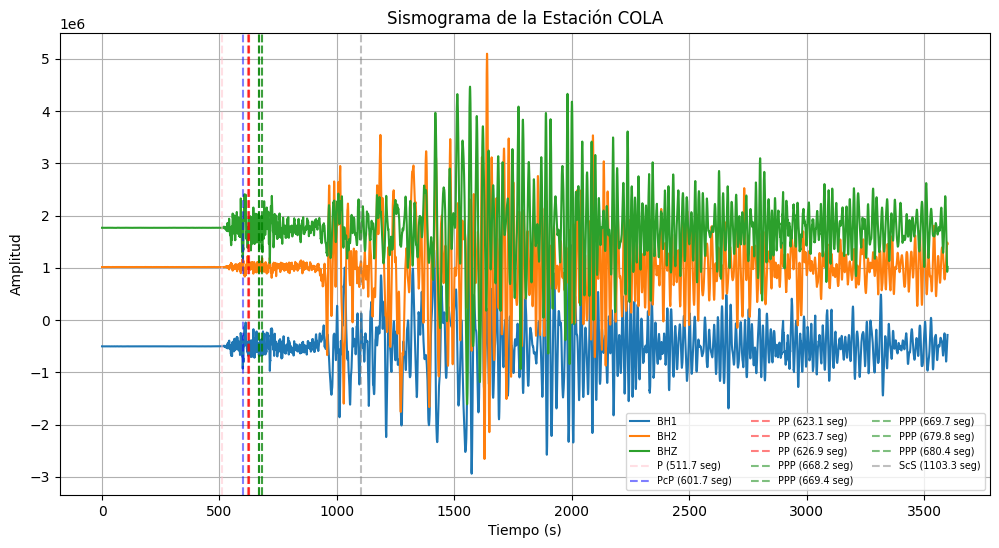

Descargando datos de la estación: TATO
Datos guardados en: TATO_Tohoku_2011.mseed
Error with this phase, skipping it: pp
Error with this phase, skipping it: ppp


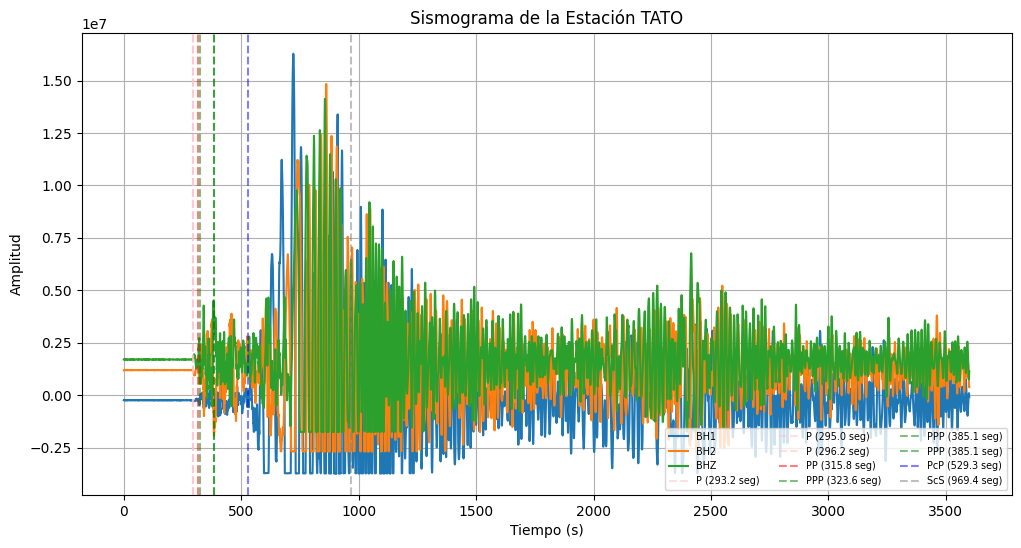

In [1]:
#Juan Diego Bernal Lopez - Tarea fases del sismo
#librerias necesarias para la ejecucion del codigo
import obspy
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
#creacion de la funcion con los datos del sismo
def tohoku_sismograma():
    #parametros del evento
    event_time = UTCDateTime("2011-03-11T05:46:23")
    event_latitude = 38.321944
    event_longitude = 142.368889
    event_depth_km = 29
    client = Client("IRIS")
    model = TauPyModel(model="iasp91")

    #Estaciones
    stations = [
        {"network": "IU", "station": "ANMO", "location": "00", "latitude": 34.9459, "longitude": -106.4572, "channels": ["BH1", "BH2", "BHZ"]},
        {"network": "IU", "station": "COLA", "location": "00", "latitude": 64.8747, "longitude": -147.8607, "channels": ["BH1", "BH2", "BHZ"]},
        {"network": "IU", "station": "TATO", "location": "00", "latitude": 24.968, "longitude": 121.497, "channels": ["BH1", "BH2", "BHZ"]}
    ]
    #parametros de inicio
    start_offset = 0
    duration = 3600

    #definicion de las fases en un diccionarion para su posterior uso de los colores
    phases_colors = {
        "PcP": "blue",
        "PP": "red",
        "pp": "black",
        "PPP": "green",
        "ppp": "cyan",
        "ScS": "gray",
        "P": "pink"
    }

    for station in stations:
        try:
            print(f"Descargando datos de la estación: {station['station']}")
            streams = []

            for channel in station["channels"]:
                st = client.get_waveforms(
                    network=station["network"],
                    station=station["station"],
                    location=station["location"],
                    channel=channel,
                    starttime=event_time + start_offset,
                    endtime=event_time + start_offset + duration
                )
                streams.append(st[0])

            #combinar trazas sismicas
            combined_stream = obspy.Stream(traces=streams)
            output_file = f"{station['station']}_Tohoku_2011.mseed"
            combined_stream.write(output_file, format="MSEED")
            print(f"Datos guardados en: {output_file}")

            #calcular los tiempos de arribo
            travel_times = model.get_travel_times_geo(
                source_depth_in_km=event_depth_km,
                source_latitude_in_deg=event_latitude,
                source_longitude_in_deg=event_longitude,
                receiver_latitude_in_deg=station["latitude"],
                receiver_longitude_in_deg=station["longitude"],
                phase_list=list(phases_colors.keys())
            )

            #sismograma
            plt.figure(figsize=(12, 6))
            for i, trace in enumerate(combined_stream):
                plt.plot(trace.times(), trace.data + i * 1e6, label=f"{trace.stats.channel}")

            #fases
            for arrival in travel_times:
                phase = arrival.phase.name
                color = phases_colors.get(phase, "black")
                plt.axvline(x=arrival.time, color=color, linestyle="--", alpha=0.5, label=f"{phase} ({arrival.time:.1f} seg)")

            plt.title(f"Sismograma de la Estación {station['station']}")
            plt.xlabel("Tiempo (s)")
            plt.ylabel("Amplitud")
            plt.legend(loc="lower right", fontsize="x-small", ncol=3)
            plt.grid()
            plt.show()

        except Exception as e:
            print(f"Error descargando datos para la estación {station['station']}: {e}")

if __name__ == "__main__":
    tohoku_sismograma()
